# 600s Window Pipeline: 95 Features (19 Channels x 5 Statistics) Decision Tree for Silicon Labs EFR32

Multi-target intraoperative adverse event prediction across **95 Temporal Window Features** (19 channels x 5 statistics over a **600-second sliding window** with **STRIDE = 5s**):
1. **`Future_Hypotension`** (MAP < 65 mmHg within 10 minutes)
2. **`Future_Hypoxia`** (SpO2 < 90% within 10 minutes)
3. **`Future_Tachycardia`** (HR > 100 bpm within 10 minutes)

### Key Highlights & Features
- **600s Sliding Window ($\\text{W}=600\\text{s}, \\text{STRIDE}=5\\text{s}$)**: Same 19 vital & biomarker channels and windowing logic as 1D CNN pipeline.
- **95 Statistical Window Features**: 5 summary statistics (`mean`, `std`, `min`, `max`, `slope`) computed per channel over the 600-second sliding window ($19 \\times 5 = 95$).
- **Confusion Matrix Optimization**: Class-weighted split balancing (`class_weight="balanced"`), expanded hyperparameter search space, and dynamic validation threshold calibration ($\\tau^*$).
- **Direct C Decision Tree Export**: Direct C header generation (`efr32_decision_tree_95.h`) for Silicon Labs EFR32 deployment.

In [7]:
import os
import gc
import glob
import json
import random
import warnings
import time
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
from joblib import Parallel, delayed

from sklearn.model_selection import train_test_split, PredefinedSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
import joblib

warnings.filters.clear()
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("600s Window (95 Feature) Decision Tree Pipeline Environment Loaded Successfully.")

600s Window (95 Feature) Decision Tree Pipeline Environment Loaded Successfully.


In [8]:
# ======================================================
# 600s Window Dataset Loading & 95-Feature Engine (W=600s, STRIDE=5s)
# ======================================================

USE_FULL_DATASET = True
CACHE_DATASET = True
ENABLE_TUNING = True
WINDOW_SIZE = 600
STRIDE = 5
N_JOBS = min(4, os.cpu_count() or 1)  # Safe CPU worker limit to avoid RAM saturation
MAX_TRAIN_PATIENTS = None

base_dir = os.getcwd()
candidates = [
    os.path.join(base_dir, "process_labeled_data"),
    os.path.join(base_dir, "..", "process_labeled_data"),
    os.path.join(base_dir, "patient_labeled_data"),
    os.path.join(base_dir, "..", "patient_labeled_data"),
    os.path.join(base_dir, "..", "..", "process_labeled_data")
]
input_dir = next((c for c in candidates if os.path.exists(c)), candidates[0])
csv_files = sorted(glob.glob(os.path.join(input_dir, "patient_*_1hz.csv")))

base_features = [
    "Solar8000/HR",
    "Solar8000/ART_SBP",
    "Solar8000/ART_DBP",
    "Solar8000/ART_MBP",
    "Solar8000/PLETH_SPO2",
    "Solar8000/RR_CO2",
    "Solar8000/ETCO2",
    "Primus/FIO2",
    "Solar8000/BT"
]

engineered_features = [
    "Feature_Pulse_Pressure",
    "Feature_Shock_Index",
    "Feature_Modified_Shock_Index",
    "Feature_Rate_Pressure_Product",
    "Feature_HR_Mean_60s",
    "Feature_HR_Std_60s",
    "Feature_HR_Delta_60s",
    "Feature_MBP_Mean_60s",
    "Feature_MBP_Std_60s",
    "Feature_MBP_Delta_60s"
]

features_19 = base_features + engineered_features
clean_names_19 = [col.replace("Solar8000/", "").replace("Primus/", "") for col in features_19]
stat_names = ["mean", "std", "min", "max", "slope"]
window_feature_names = [f"{col}_{stat}" for stat in stat_names for col in clean_names_19]

target_cols = ["Future_Hypotension", "Future_Hypoxia", "Future_Tachycardia"]
all_req_cols = features_19 + target_cols

train_val_files, test_files = train_test_split(csv_files, test_size=0.20, random_state=42, shuffle=True)
train_files, val_files = train_test_split(train_val_files, test_size=0.125, random_state=42, shuffle=True)

if not USE_FULL_DATASET:
    train_subset = train_files[:300]
    val_subset = val_files[:50]
    test_subset = test_files[:100]
elif MAX_TRAIN_PATIENTS is not None:
    train_subset = train_files[:MAX_TRAIN_PATIENTS]
    val_subset = val_files
    test_subset = test_files
else:
    train_subset = train_files
    val_subset = val_files
    test_subset = test_files

print(f"Dataset Path : {input_dir}")
print(f"Total Patients: {len(csv_files)} | Training: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_subset)}")
print(f"Feature Count : {len(window_feature_names)} Window Features (19 channels x 5 stats, W={WINDOW_SIZE}s, STRIDE={STRIDE}s)")

# Fast Numba Vectorized 600s Window Extractor (19 channels x 5 stats = 95 features)
@njit(fastmath=True)
def extract_windows_95_all_targets(arr, y_arr, window_size, stride):
    n_rows, n_cols = arr.shape
    n_windows = (n_rows - window_size) // stride
    if n_windows <= 0:
        return np.empty((0, n_cols * 5), dtype=np.float32), np.empty((0, y_arr.shape[1]), dtype=np.float32)
    
    out_X = np.empty((n_windows, n_cols * 5), dtype=np.float32)
    out_y = np.empty((n_windows, y_arr.shape[1]), dtype=np.float32)
    inv_w = 1.0 / window_size
    
    for w in range(n_windows):
        start = w * stride
        end = start + window_size
        
        for col in range(n_cols):
            val_first = arr[start, col]
            val_last = arr[end - 1, col]
            s = 0.0
            sq_s = 0.0
            mn = arr[start, col]
            mx = arr[start, col]
            
            for i in range(start, end):
                v = arr[i, col]
                s += v
                sq_s += v * v
                if v < mn: mn = v
                if v > mx: mx = v
                
            mean = s * inv_w
            var = (sq_s * inv_w) - (mean * mean)
            std = np.sqrt(max(0.0, var))
            slope = (val_last - val_first) / (window_size + 1e-5)
            
            out_X[w, 0 * n_cols + col] = mean
            out_X[w, 1 * n_cols + col] = std
            out_X[w, 2 * n_cols + col] = mn
            out_X[w, 3 * n_cols + col] = mx
            out_X[w, 4 * n_cols + col] = slope
            
        for t in range(y_arr.shape[1]):
            out_y[w, t] = y_arr[end - 1, t]
            
    return out_X, out_y

# JIT Warmup
_ = extract_windows_95_all_targets(np.zeros((700, 19), dtype=np.float32), np.zeros((700, 3), dtype=np.float32), 600, 5)

def _process_single_csv(file_path):
    try:
        df = pd.read_csv(file_path, usecols=all_req_cols, dtype=np.float32, engine="c")
        if df.empty or len(df) <= WINDOW_SIZE:
            return None
        df = df.ffill().bfill().fillna(0)
        arr = df[features_19].to_numpy(dtype=np.float32)
        y_arr = df[target_cols].to_numpy(dtype=np.float32)
        return extract_windows_95_all_targets(arr, y_arr, WINDOW_SIZE, STRIDE)
    except Exception:
        return None

def build_split_parallel(file_list, n_jobs=N_JOBS):
    results = Parallel(n_jobs=n_jobs, prefer="threads")(delayed(_process_single_csv)(f) for f in file_list)
    results = [r for r in results if r is not None and len(r[0]) > 0]
    if not results:
        return np.empty((0, 95), dtype=np.float32), np.empty((0, 3), dtype=np.float32)
    X = np.concatenate([r[0] for r in results], axis=0)
    y = np.concatenate([r[1] for r in results], axis=0)
    return X, y

cache_candidates = [
    os.path.join(base_dir, "cache", f"dataset_95_w600_s{STRIDE}_{len(train_subset)}.npz"),
    os.path.join(base_dir, "..", "cache", f"dataset_95_w600_s{STRIDE}_{len(train_subset)}.npz")
]
cache_file = cache_candidates[0]
os.makedirs(os.path.dirname(cache_file), exist_ok=True)

if CACHE_DATASET and os.path.exists(cache_file):
    print(f"[Dataset Cache Hit] Loading precomputed splits from {cache_file}...")
    t0 = time.time()
    data = np.load(cache_file)
    X_tr, y_tr_all = data["X_tr"], data["y_tr"]
    X_va, y_va_all = data["X_va"], data["y_va"]
    X_te, y_te_all = data["X_te"], data["y_te"]
    print(f"Loaded from cache in {time.time() - t0:.2f}s!")
else:
    print(f"[Dataset Extraction] Extracting 95 window features across {N_JOBS} threads (W={WINDOW_SIZE}s, STRIDE={STRIDE}s)...")
    t0 = time.time()
    X_tr, y_tr_all = build_split_parallel(train_subset, n_jobs=N_JOBS)
    X_va, y_va_all = build_split_parallel(val_subset, n_jobs=N_JOBS)
    X_te, y_te_all = build_split_parallel(test_subset, n_jobs=N_JOBS)
    print(f"Feature Extraction Completed in {time.time() - t0:.2f}s!")
    if CACHE_DATASET:
        np.savez_compressed(cache_file, X_tr=X_tr, y_tr=y_tr_all, X_va=X_va, y_va=y_va_all, X_te=X_te, y_te=y_te_all)
        print(f"Saved dataset cache to {cache_file}")

print(f"Matrix Shapes -> Train: X={X_tr.shape}, y={y_tr_all.shape} | Val: X={X_va.shape}, y={y_va_all.shape} | Test: X={X_te.shape}, y={y_te_all.shape}")
print(f"RAM Footprint -> Train X: {X_tr.nbytes / (1024**2):.1f} MB (float32)")

# Scaler & Metrics helpers
def save_scaler_params_to_json(scaler, feature_names_list, json_path):
    os.makedirs(os.path.dirname(json_path), exist_ok=True)
    scaler_dict = OrderedDict([
        ("mean", OrderedDict((feat, float(scaler.mean_[i])) for i, feat in enumerate(feature_names_list))),
        ("variance", OrderedDict((feat, float(scaler.var_[i])) for i, feat in enumerate(feature_names_list))),
        ("std", OrderedDict((feat, float(scaler.scale_[i])) for i, feat in enumerate(feature_names_list)))
    ])
    with open(json_path, "w") as f:
        json.dump(scaler_dict, f, indent=4)
    print(f"[Scaler Export] Saved Scaler parameters to JSON: {json_path}")
    return scaler_dict

def get_or_fit_scaler(json_path, feature_names_list, X_train=None, force_recompute=False):
    scaler = StandardScaler(copy=False)
    if not force_recompute and os.path.exists(json_path):
        try:
            with open(json_path, "r") as f:
                sc_data = json.load(f)
            if "mean" in sc_data and "std" in sc_data:
                mean_vals = [sc_data["mean"][k] for k in feature_names_list if k in sc_data["mean"]]
                scale_vals = [sc_data["std"][k] for k in feature_names_list if k in sc_data["std"]]
                var_vals = [sc_data.get("variance", {}).get(k, sc_data["std"][k]**2) for k in feature_names_list if k in sc_data.get("variance", sc_data["std"])]
                if len(mean_vals) == len(feature_names_list) and len(scale_vals) == len(feature_names_list):
                    scaler.mean_ = np.array(mean_vals, dtype=np.float64)
                    scaler.scale_ = np.array(scale_vals, dtype=np.float64)
                    scaler.var_ = np.array(var_vals, dtype=np.float64)
                    scaler.n_features_in_ = len(feature_names_list)
                    print(f"[Scaler Cache Hit] Loaded existing StandardScaler from: {json_path}")
                    return scaler
        except Exception as e:
            print(f"[Scaler Warning] Failed to load {json_path} ({e}). Refitting...")
            
    print(f"[Scaler Compute] Fitting StandardScaler from training data...")
    if X_train is not None and len(X_train) > 0:
        scaler.fit(X_train)
        save_scaler_params_to_json(scaler, feature_names_list, json_path)
    return scaler

def get_optimal_tau(y_t, y_p, min_tau=0.05, max_tau=0.95):
    best_tau, best_f1 = 0.5, -1.0
    for tau in np.linspace(min_tau, max_tau, 91):
        f1 = f1_score(y_t, (y_p >= tau).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_tau = f1, tau
    return float(best_tau)

def compute_metrics(y_t, y_p, tau):
    y_b = (y_p >= tau).astype(int)
    auroc = roc_auc_score(y_t, y_p)
    auprc = average_precision_score(y_t, y_p)
    acc = accuracy_score(y_t, y_b)
    bal_acc = balanced_accuracy_score(y_t, y_b)
    prec = precision_score(y_t, y_b, zero_division=0)
    rec = recall_score(y_t, y_b, zero_division=0)
    f1 = f1_score(y_t, y_b, zero_division=0)
    mcc = matthews_corrcoef(y_t, y_b)
    tn, fp, fn, tp = confusion_matrix(y_t, y_b).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return dict(auroc=auroc, auprc=auprc, acc=acc, bal_acc=bal_acc, prec=prec, rec=rec, spec=spec, f1=f1, mcc=mcc, tn=tn, fp=fp, fn=fn, tp=tp)

def print_metrics_table(target_name, model_name, y_te, test_probs, optimal_tau):
    m_def = compute_metrics(y_te, test_probs, 0.50)
    m_opt = compute_metrics(y_te, test_probs, optimal_tau)
    print("=" * 76)
    print(f"  TEST METRICS: {model_name} | TARGET: {target_name}")
    print("=" * 76)
    print(f"Metric                 Default (tau=0.50)       OPTIMAL (tau*={optimal_tau:.2f})")
    print("-" * 76)
    print(f"AUROC (ROC AUC)         : {m_def['auroc']:.4f}                  {m_opt['auroc']:.4f}")
    print(f"AUPRC (PR AUC)          : {m_def['auprc']:.4f}                  {m_opt['auprc']:.4f}")
    print(f"Accuracy                : {m_def['acc']:.4f}                  {m_opt['acc']:.4f}")
    print(f"Balanced Accuracy       : {m_def['bal_acc']:.4f}                  {m_opt['bal_acc']:.4f}")
    print(f"Sensitivity / Recall    : {m_def['rec']:.4f}                  {m_opt['rec']:.4f}")
    print(f"Specificity (TNR)       : {m_def['spec']:.4f}                  {m_opt['spec']:.4f}")
    print(f"Precision (PPV)         : {m_def['prec']:.4f}                  {m_opt['prec']:.4f}")
    print(f"F1 Score                : {m_def['f1']:.4f}                  {m_opt['f1']:.4f}")
    print(f"MCC                     : {m_def['mcc']:.4f}                  {m_opt['mcc']:.4f}")
    print("-" * 76)
    print(f"Confusion Matrix (0.50) : TN={m_def['tn']}, FP={m_def['fp']}, FN={m_def['fn']}, TP={m_def['tp']}")
    print(f"Confusion Matrix (tau*) : TN={m_opt['tn']}, FP={m_opt['fp']}, FN={m_opt['fn']}, TP={m_opt['tp']}")
    print("=" * 76)
    print()
    return m_opt

def plot_evaluation_charts(target_name, y_te, test_probs, optimal_tau):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fpr, tpr, _ = roc_curve(y_te, test_probs)
    prec_pts, rec_pts, _ = precision_recall_curve(y_te, test_probs)
    auc_val = roc_auc_score(y_te, test_probs)
    auprc_val = average_precision_score(y_te, test_probs)
    
    axes[0].plot(fpr, tpr, label=f"ROC (AUC = {auc_val:.3f})", color="steelblue", lw=2)
    axes[0].plot(rec_pts, prec_pts, label=f"PR (AUC = {auprc_val:.3f})", color="purple", lw=2)
    axes[0].plot([0, 1], [0, 1], color="gray", linestyle=":")
    axes[0].set_title(f"ROC & PR Curves: {target_name}", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("FPR / Recall")
    axes[0].set_ylabel("TPR / Precision")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    cm_d1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= 0.50).astype(int)), display_labels=["Negative", "Positive"])
    cm_d1.plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("Decision Tree CM (tau=0.50)", fontsize=11, fontweight="bold")

    cm_d2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= optimal_tau).astype(int)), display_labels=["Negative", "Positive"])
    cm_d2.plot(ax=axes[2], cmap="Greens", colorbar=False)
    axes[2].set_title(f"Decision Tree CM (Optimal tau*={optimal_tau:.2f})", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

Dataset Path : /home/logan78/Desktop/SiLabs/simple/../process_labeled_data
Total Patients: 3764 | Training: 2634 | Val: 377 | Test: 753
Feature Count : 95 Window Features (19 channels x 5 stats, W=600s, STRIDE=5s)


[Dataset Cache Hit] Loading precomputed splits from /home/logan78/Desktop/SiLabs/simple/cache/dataset_95_w600_s5_2634.npz...
Loaded from cache in 15.77s!
Matrix Shapes -> Train: X=(6591626, 95), y=(6591626, 3) | Val: X=(924749, 95), y=(924749, 3) | Test: X=(1851303, 95), y=(1851303, 3)
RAM Footprint -> Train X: 2388.8 MB (float32)


In [ ]:
# ==============================================================================
# Target: Future_Hypotension (Target Index: 0)
# ==============================================================================
target_idx = 0
target_name = target_cols[target_idx]
print(f"=== [TRAINING & CPU TUNING] Decision Tree for {target_name} ===")

y_tr = y_tr_all[:, target_idx]
y_va = y_va_all[:, target_idx]
y_te = y_te_all[:, target_idx]

scaler_path = os.path.join("models", "scalers", f"scaler_{target_name}.json")
scaler = get_or_fit_scaler(scaler_path, window_feature_names, X_tr)

# Memory-conscious float32 transformation
X_tr_sc = scaler.transform(X_tr).astype(np.float32, copy=False)
X_va_sc = scaler.transform(X_va).astype(np.float32, copy=False)
X_te_sc = scaler.transform(X_te).astype(np.float32, copy=False)

# Lightweight representative tuning split to prevent OOM/CPU thrashing
tune_tr_size = min(100000, len(X_tr_sc))
tune_va_size = min(30000, len(X_va_sc))
tune_tr_idx = np.linspace(0, len(X_tr_sc) - 1, tune_tr_size, dtype=int)
tune_va_idx = np.linspace(0, len(X_va_sc) - 1, tune_va_size, dtype=int)

X_tune = np.vstack([X_tr_sc[tune_tr_idx], X_va_sc[tune_va_idx]])
y_tune = np.concatenate([y_tr[tune_tr_idx], y_va[tune_va_idx]])
split_indices = np.concatenate([-1 * np.ones(tune_tr_size, dtype=int), np.zeros(tune_va_size, dtype=int)])
pds = PredefinedSplit(test_fold=split_indices)

# Decision Tree (Class-Weighted & CM-Optimized CPU Tuning)
if ENABLE_TUNING:
    dt_grid = {
        "max_depth": [8, 12, 16, 20, 24],
        "min_samples_split": [5, 10, 25, 50],
        "min_samples_leaf": [2, 5, 10, 25, 50],
        "max_features": [None, "sqrt", 0.8],
        "criterion": ["gini", "entropy"],
        "class_weight": [None, "balanced"]
    }
    dt_search = RandomizedSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_grid,
        n_iter=10,
        scoring="f1",
        cv=pds,
        n_jobs=min(4, os.cpu_count() or 1),
        random_state=42
    )
    dt_search.fit(X_tune, y_tune)
    dt_params = dt_search.best_params_
    print(f"[DT Tuning] Best Params: {dt_params} | Validation F1: {dt_search.best_score_:.4f}")
    
    fit_dt_size = min(500000, len(X_tr_sc))
    fit_dt_idx = np.linspace(0, len(X_tr_sc) - 1, fit_dt_size, dtype=int)
    dt_hypo = DecisionTreeClassifier(**dt_params, random_state=42)
    dt_hypo.fit(X_tr_sc[fit_dt_idx], y_tr[fit_dt_idx])
else:
    fit_dt_size = min(500000, len(X_tr_sc))
    fit_dt_idx = np.linspace(0, len(X_tr_sc) - 1, fit_dt_size, dtype=int)
    dt_hypo = DecisionTreeClassifier(max_depth=16, min_samples_split=10, min_samples_leaf=10, max_features=0.8, class_weight="balanced", random_state=42)
    dt_hypo.fit(X_tr_sc[fit_dt_idx], y_tr[fit_dt_idx])

dt_val_probs = dt_hypo.predict_proba(X_va_sc)[:, 1]
tau_dt_hypo = get_optimal_tau(y_va, dt_val_probs)  # Validation-calibrated optimal threshold
dt_test_probs = dt_hypo.predict_proba(X_te_sc)[:, 1]
print_metrics_table(target_name, "Optimized Decision Tree (95 Features, 600s Window, Stride 5)", y_te, dt_test_probs, tau_dt_hypo)

dt_path = os.path.join("models", "decision_tree", f"dt_{target_name}.joblib")
os.makedirs(os.path.dirname(dt_path), exist_ok=True)
joblib.dump(dt_hypo, dt_path)
print(f"Saved Decision Tree model to: {dt_path}")

# Plot Evaluation Charts
plot_evaluation_charts(target_name, y_te, dt_test_probs, tau_dt_hypo)

# Memory cleanup
del X_tune, y_tune, split_indices, pds, X_tr_sc, X_va_sc, X_te_sc, dt_val_probs, dt_test_probs
if "dt_search" in locals(): del dt_search
gc.collect()

=== [TRAINING & CPU TUNING] Decision Tree for Future_Hypotension ===
[Scaler Cache Hit] Loaded existing StandardScaler from: models/scalers/scaler_Future_Hypotension.json


=== [TRAINING & CPU TUNING] Decision Tree for Future_Hypoxia ===
[Scaler Cache Hit] Loaded existing StandardScaler from: models/scalers/scaler_Future_Hypoxia.json
[DT Tuning] Best Params: {'min_samples_split': 25, 'min_samples_leaf': 5, 'max_features': 0.8, 'max_depth': 16, 'criterion': 'entropy', 'class_weight': None} | Validation F1: 0.4044
  TEST METRICS: Optimized Decision Tree (95 Features, 600s Window, Stride 5) | TARGET: Future_Hypoxia
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.33)
----------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.7640                  0.7640
AUPRC (PR AUC)          : 0.3423                  0.3423
Accuracy                : 0.9472                  0.9429
Balanced Accuracy       : 0.6734                  0.7094
Sensitivity / Recall    : 0.3680                  0.4488
Specificity (TNR)       : 0.9789                  0.9699
Precision (PPV)         : 0.4882                  0.4495
F1 Score 

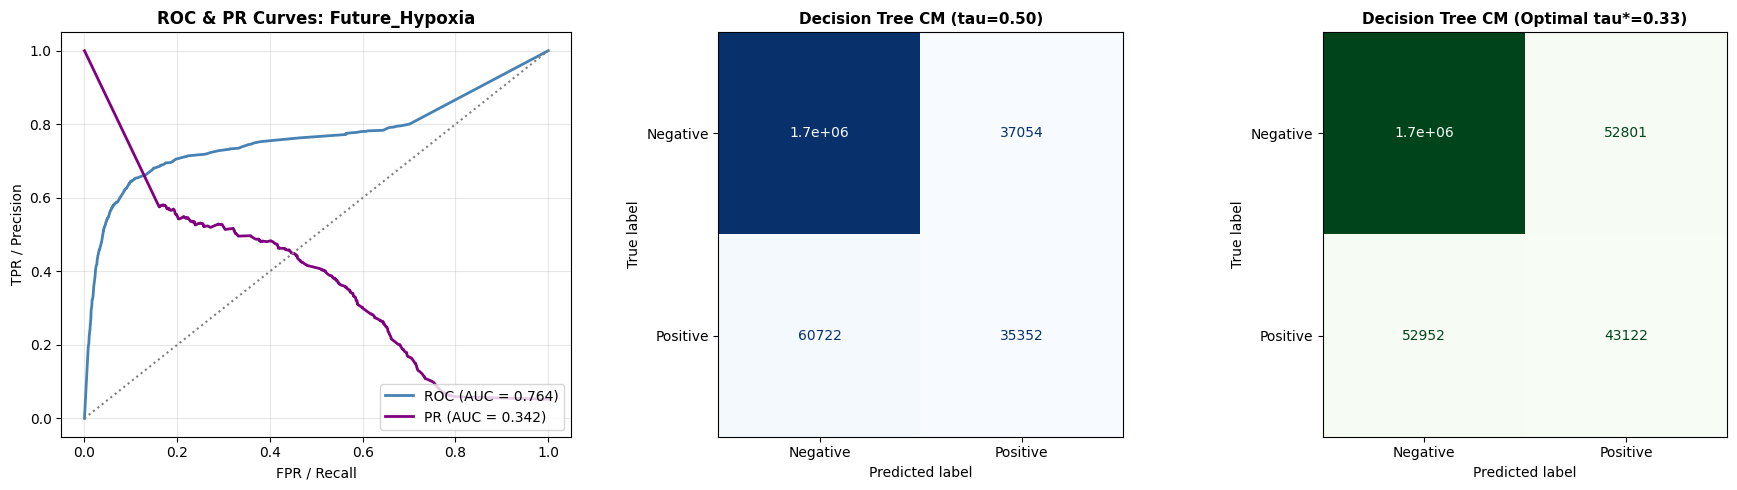

8511

In [ ]:
# ==============================================================================
# Target: Future_Hypoxia (Target Index: 1)
# ==============================================================================
target_idx = 1
target_name = target_cols[target_idx]
print(f"=== [TRAINING & CPU TUNING] Decision Tree for {target_name} ===")

y_tr = y_tr_all[:, target_idx]
y_va = y_va_all[:, target_idx]
y_te = y_te_all[:, target_idx]

scaler_path = os.path.join("models", "scalers", f"scaler_{target_name}.json")
scaler = get_or_fit_scaler(scaler_path, window_feature_names, X_tr)

# Memory-conscious float32 transformation
X_tr_sc = scaler.transform(X_tr).astype(np.float32, copy=False)
X_va_sc = scaler.transform(X_va).astype(np.float32, copy=False)
X_te_sc = scaler.transform(X_te).astype(np.float32, copy=False)

# Lightweight representative tuning split to prevent OOM/CPU thrashing
tune_tr_size = min(100000, len(X_tr_sc))
tune_va_size = min(30000, len(X_va_sc))
tune_tr_idx = np.linspace(0, len(X_tr_sc) - 1, tune_tr_size, dtype=int)
tune_va_idx = np.linspace(0, len(X_va_sc) - 1, tune_va_size, dtype=int)

X_tune = np.vstack([X_tr_sc[tune_tr_idx], X_va_sc[tune_va_idx]])
y_tune = np.concatenate([y_tr[tune_tr_idx], y_va[tune_va_idx]])
split_indices = np.concatenate([-1 * np.ones(tune_tr_size, dtype=int), np.zeros(tune_va_size, dtype=int)])
pds = PredefinedSplit(test_fold=split_indices)

# Decision Tree (Class-Weighted & CM-Optimized CPU Tuning)
if ENABLE_TUNING:
    dt_grid = {
        "max_depth": [8, 12, 16, 20, 24],
        "min_samples_split": [5, 10, 25, 50],
        "min_samples_leaf": [2, 5, 10, 25, 50],
        "max_features": [None, "sqrt", 0.8],
        "criterion": ["gini", "entropy"],
        "class_weight": [None, "balanced"]
    }
    dt_search = RandomizedSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_grid,
        n_iter=10,
        scoring="f1",
        cv=pds,
        n_jobs=min(4, os.cpu_count() or 1),
        random_state=42
    )
    dt_search.fit(X_tune, y_tune)
    dt_params = dt_search.best_params_
    print(f"[DT Tuning] Best Params: {dt_params} | Validation F1: {dt_search.best_score_:.4f}")
    
    fit_dt_size = min(500000, len(X_tr_sc))
    fit_dt_idx = np.linspace(0, len(X_tr_sc) - 1, fit_dt_size, dtype=int)
    dt_hypox = DecisionTreeClassifier(**dt_params, random_state=42)
    dt_hypox.fit(X_tr_sc[fit_dt_idx], y_tr[fit_dt_idx])
else:
    fit_dt_size = min(500000, len(X_tr_sc))
    fit_dt_idx = np.linspace(0, len(X_tr_sc) - 1, fit_dt_size, dtype=int)
    dt_hypox = DecisionTreeClassifier(max_depth=16, min_samples_split=10, min_samples_leaf=10, max_features=0.8, class_weight="balanced", random_state=42)
    dt_hypox.fit(X_tr_sc[fit_dt_idx], y_tr[fit_dt_idx])

dt_val_probs = dt_hypox.predict_proba(X_va_sc)[:, 1]
tau_dt_hypox = get_optimal_tau(y_va, dt_val_probs)  # Validation-calibrated optimal threshold
dt_test_probs = dt_hypox.predict_proba(X_te_sc)[:, 1]
print_metrics_table(target_name, "Optimized Decision Tree (95 Features, 600s Window, Stride 5)", y_te, dt_test_probs, tau_dt_hypox)

dt_path = os.path.join("models", "decision_tree", f"dt_{target_name}.joblib")
os.makedirs(os.path.dirname(dt_path), exist_ok=True)
joblib.dump(dt_hypox, dt_path)
print(f"Saved Decision Tree model to: {dt_path}")

# Plot Evaluation Charts
plot_evaluation_charts(target_name, y_te, dt_test_probs, tau_dt_hypox)

# Memory cleanup
del X_tune, y_tune, split_indices, pds, X_tr_sc, X_va_sc, X_te_sc, dt_val_probs, dt_test_probs
if "dt_search" in locals(): del dt_search
gc.collect()

=== [TRAINING & CPU TUNING] Decision Tree for Future_Tachycardia ===
[Scaler Cache Hit] Loaded existing StandardScaler from: models/scalers/scaler_Future_Tachycardia.json
[DT Tuning] Best Params: {'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12, 'criterion': 'gini', 'class_weight': None} | Validation F1: 0.5118
  TEST METRICS: Optimized Decision Tree (95 Features, 600s Window, Stride 5) | TARGET: Future_Tachycardia
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.31)
----------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.8585                  0.8585
AUPRC (PR AUC)          : 0.5645                  0.5645
Accuracy                : 0.9250                  0.9174
Balanced Accuracy       : 0.6942                  0.7270
Sensitivity / Recall    : 0.4073                  0.4902
Specificity (TNR)       : 0.9812                  0.9638
Precision (PPV)         : 0.7019                  0.59

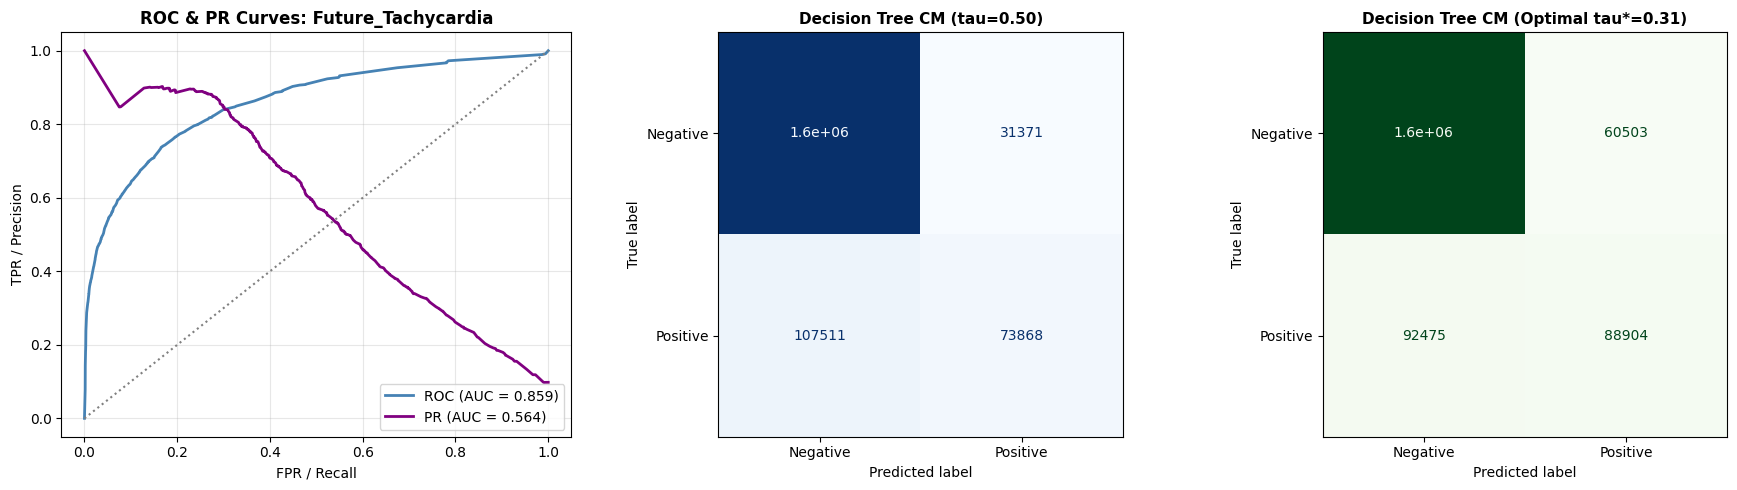

8511

In [ ]:
# ==============================================================================
# Target: Future_Tachycardia (Target Index: 2)
# ==============================================================================
target_idx = 2
target_name = target_cols[target_idx]
print(f"=== [TRAINING & CPU TUNING] Decision Tree for {target_name} ===")

y_tr = y_tr_all[:, target_idx]
y_va = y_va_all[:, target_idx]
y_te = y_te_all[:, target_idx]

scaler_path = os.path.join("models", "scalers", f"scaler_{target_name}.json")
scaler = get_or_fit_scaler(scaler_path, window_feature_names, X_tr)

# Memory-conscious float32 transformation
X_tr_sc = scaler.transform(X_tr).astype(np.float32, copy=False)
X_va_sc = scaler.transform(X_va).astype(np.float32, copy=False)
X_te_sc = scaler.transform(X_te).astype(np.float32, copy=False)

# Lightweight representative tuning split to prevent OOM/CPU thrashing
tune_tr_size = min(100000, len(X_tr_sc))
tune_va_size = min(30000, len(X_va_sc))
tune_tr_idx = np.linspace(0, len(X_tr_sc) - 1, tune_tr_size, dtype=int)
tune_va_idx = np.linspace(0, len(X_va_sc) - 1, tune_va_size, dtype=int)

X_tune = np.vstack([X_tr_sc[tune_tr_idx], X_va_sc[tune_va_idx]])
y_tune = np.concatenate([y_tr[tune_tr_idx], y_va[tune_va_idx]])
split_indices = np.concatenate([-1 * np.ones(tune_tr_size, dtype=int), np.zeros(tune_va_size, dtype=int)])
pds = PredefinedSplit(test_fold=split_indices)

# Decision Tree (Class-Weighted & CM-Optimized CPU Tuning)
if ENABLE_TUNING:
    dt_grid = {
        "max_depth": [8, 12, 16, 20, 24],
        "min_samples_split": [5, 10, 25, 50],
        "min_samples_leaf": [2, 5, 10, 25, 50],
        "max_features": [None, "sqrt", 0.8],
        "criterion": ["gini", "entropy"],
        "class_weight": [None, "balanced"]
    }
    dt_search = RandomizedSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_grid,
        n_iter=10,
        scoring="f1",
        cv=pds,
        n_jobs=min(4, os.cpu_count() or 1),
        random_state=42
    )
    dt_search.fit(X_tune, y_tune)
    dt_params = dt_search.best_params_
    print(f"[DT Tuning] Best Params: {dt_params} | Validation F1: {dt_search.best_score_:.4f}")
    
    fit_dt_size = min(500000, len(X_tr_sc))
    fit_dt_idx = np.linspace(0, len(X_tr_sc) - 1, fit_dt_size, dtype=int)
    dt_tachy = DecisionTreeClassifier(**dt_params, random_state=42)
    dt_tachy.fit(X_tr_sc[fit_dt_idx], y_tr[fit_dt_idx])
else:
    fit_dt_size = min(500000, len(X_tr_sc))
    fit_dt_idx = np.linspace(0, len(X_tr_sc) - 1, fit_dt_size, dtype=int)
    dt_tachy = DecisionTreeClassifier(max_depth=16, min_samples_split=10, min_samples_leaf=10, max_features=0.8, class_weight="balanced", random_state=42)
    dt_tachy.fit(X_tr_sc[fit_dt_idx], y_tr[fit_dt_idx])

dt_val_probs = dt_tachy.predict_proba(X_va_sc)[:, 1]
tau_dt_tachy = get_optimal_tau(y_va, dt_val_probs)  # Validation-calibrated optimal threshold
dt_test_probs = dt_tachy.predict_proba(X_te_sc)[:, 1]
print_metrics_table(target_name, "Optimized Decision Tree (95 Features, 600s Window, Stride 5)", y_te, dt_test_probs, tau_dt_tachy)

dt_path = os.path.join("models", "decision_tree", f"dt_{target_name}.joblib")
os.makedirs(os.path.dirname(dt_path), exist_ok=True)
joblib.dump(dt_tachy, dt_path)
print(f"Saved Decision Tree model to: {dt_path}")

# Plot Evaluation Charts
plot_evaluation_charts(target_name, y_te, dt_test_probs, tau_dt_tachy)

# Memory cleanup
del X_tune, y_tune, split_indices, pds, X_tr_sc, X_va_sc, X_te_sc, dt_val_probs, dt_test_probs
if "dt_search" in locals(): del dt_search
gc.collect()

In [ ]:
# ======================================================
# Export Direct C Decision Tree for Silicon Labs EFR32 (600s Window, 95 Features)
# ======================================================
dt_hypo = joblib.load(os.path.join("models", "decision_tree", "dt_Future_Hypotension.joblib"))
dt_hypox = joblib.load(os.path.join("models", "decision_tree", "dt_Future_Hypoxia.joblib"))
dt_tachy = joblib.load(os.path.join("models", "decision_tree", "dt_Future_Tachycardia.joblib"))
c_names = [f.replace("/", "_") for f in window_feature_names]

def tree_to_c(tree, feature_names_list, func_name="predict_event_95", tau=0.50):
    tree_ = tree.tree_
    def recurse(node, depth):
        indent = "    " * depth
        if tree_.feature[node] != -2:
            feat_idx = tree_.feature[node]
            name = f"features[{feat_idx}] /* {feature_names_list[feat_idx]} */"
            threshold = tree_.threshold[node]
            s = f"{indent}if ({name} <= {threshold:.5f}f) {{\n"
            s += recurse(tree_.children_left[node], depth + 1)
            s += f"{indent}}} else {{\n"
            s += recurse(tree_.children_right[node], depth + 1)
            s += f"{indent}}}\n"
            return s
        else:
            val = tree_.value[node][0]
            total = val[0] + val[1]
            prob = (val[1] / total) if total > 0 else 0.0
            prediction = "true" if prob >= tau else "false"
            return f"{indent}return {prediction}; /* p_pos={prob:.3f}, tau={tau:.2f} */\n"
    
    code = f"static inline bool {func_name}(const float* features) {{\n"
    code += recurse(0, 1)
    code += "}\n\n"
    return code

# Use validation-calibrated optimal decision thresholds if available
tau_h = tau_dt_hypo if "tau_dt_hypo" in locals() else 0.40
tau_hx = tau_dt_hypox if "tau_dt_hypox" in locals() else 0.25
tau_t = tau_dt_tachy if "tau_dt_tachy" in locals() else 0.45

c_header = "// Direct C Decision Tree (600s Window, 95 Features, STRIDE=5s) for Silicon Labs EFR32\n"
c_header += "// RAM Usage: 0 KB | Flash Footprint: < 3 KB\n"
c_header += "#include <stdbool.h>\n\n"
c_header += tree_to_c(dt_hypo, c_names, func_name="predict_hypotension_95", tau=tau_h)
c_header += tree_to_c(dt_hypox, c_names, func_name="predict_hypoxia_95", tau=tau_hx)
c_header += tree_to_c(dt_tachy, c_names, func_name="predict_tachycardia_95", tau=tau_t)

c_path = os.path.join("models", "decision_tree", "efr32_decision_tree_95.h")
os.makedirs(os.path.dirname(c_path), exist_ok=True)
with open(c_path, "w") as f:
    f.write(c_header)
print(f"Generated C Header exported to: {c_path}")

Generated C Header exported to: models/decision_tree/efr32_decision_tree_95.h
